<a href="https://colab.research.google.com/github/shalineesinghvit12-source/shalineesinghvit12-source/blob/main/Flight_Booking_Predection_G_7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Flight Booking Price Prediction

Problem Statement The flight booking platform operates in a highly dynamic pricing environment where ticket prices vary based on multiple factors such as airline, route, class, duration, and days left before departure. Currently, pricing decisions may rely on historical patterns or static rules, which can lead to: -Inconsistent pricing strategies -Revenue leakage due to underpricing -Reduced competitiveness due to overpricing -Limited visibility into key price drivers There is a need for a data-driven approach to accurately predict flight ticket prices and understand the factors influencing them.

Business Goal The primary goal of this project is to develop a machine learning model that accurately predicts flight ticket prices using historical booking data. The model should: -Improve pricing accuracy -Support dynamic pricing decisions -Identify key variables influencing ticket prices -Reduce pricing error and volatility -Enhance revenue optimization By leveraging predictive analytics, the company can transition from reactive pricing to a strategic, data-driven pricing framework.

Business Case Implementing a predictive pricing model provides measurable business value:

Revenue Optimization Accurate price prediction helps identify optimal pricing ranges, reducing underpricing and maximizing margins.

Competitive Positioning Understanding pricing patterns across airlines, routes, and classes enables smarter competitive strategies.

Operational Efficiency Automating price prediction reduces reliance on manual analysis and static pricing rules.

Strategic Insights The model highlights key drivers such as days left before departure, class type, and route, enabling better demand forecasting and pricing planning.

Conclusion This project establishes a machine learning–based pricing intelligence system that enables informed decision-making, improves revenue management, and enhances overall pricing strategy within the flight booking platform.

In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error

import matplotlib.pyplot as plt
import seaborn as sns


In [ ]:
from google.colab import files # upload local files to google collab to access it
uploaded = files.upload()
df = pd.read_csv('Flight_Booking.csv')

Saving Flight_Booking.csv to Flight_Booking (1).csv


In [ ]:
df.shape
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300153 entries, 0 to 300152
Data columns (total 12 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Unnamed: 0        300153 non-null  int64  
 1   airline           300153 non-null  object 
 2   flight            300153 non-null  object 
 3   source_city       300153 non-null  object 
 4   departure_time    300153 non-null  object 
 5   stops             300153 non-null  object 
 6   arrival_time      300153 non-null  object 
 7   destination_city  300153 non-null  object 
 8   class             300153 non-null  object 
 9   duration          300153 non-null  float64
 10  days_left         300153 non-null  int64  
 11  price             300153 non-null  int64  
dtypes: float64(1), int64(3), object(8)
memory usage: 27.5+ MB


In [ ]:
df.describe()

,Unnamed: 0,duration,days_left,price
count,300153.000000,300153.000000,300153.000000,300153.000000
mean,150076.000000,12.221021,26.004751,20889.660523
std,86646.852011,7.191997,13.561004,22697.767366
min,0.000000,0.830000,1.000000,1105.000000
25%,75038.000000,6.830000,15.000000,4783.000000
50%,150076.000000,11.250000,26.000000,7425.000000
75%,225114.000000,16.170000,38.000000,42521.000000
max,300152.000000,49.830000,49.000000,123071.000000


In [ ]:
df.isnull().sum()

,0
Unnamed: 0,0
airline,0
flight,0
source_city,0
departure_time,0
stops,0
arrival_time,0
destination_city,0
class,0
duration,0


In [ ]:
df.duplicated().sum()

np.int64(0)

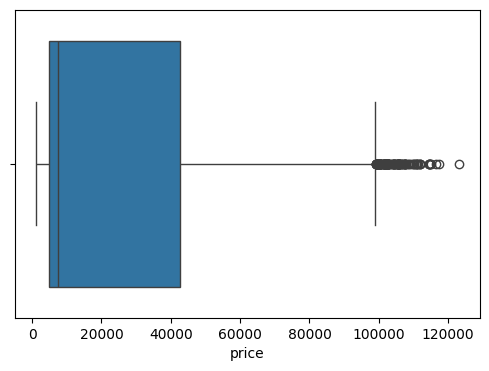

In [ ]:
import seaborn as sns
plt.figure(figsize=(6,4))
sns.boxplot(x=df['price'])
plt.show()

In [ ]:
#IQR=Q3−Q1
#IQR (Interquartile Range) is a statistical method used to detect outliers in numerical data.It measures the spread of the middle 50% of the data.
Q1 = df['price'].quantile(0.25)
Q3 = df['price'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

In [ ]:
df['price'] = np.where(df['price'] > upper, upper,
                np.where(df['price'] < lower, lower, df['price']))

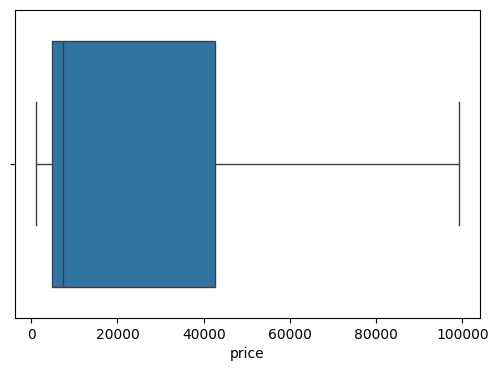

In [ ]:
plt.figure(figsize=(6,4))
sns.boxplot(x=df['price'])
plt.show()

In [ ]:
df_encoded = pd.get_dummies(df, drop_first=True)

In [ ]:
#X contains all independent variables (predictors)
X = df_encoded.drop('price', axis=1)
y = df_encoded['price']

In [ ]:
X = X.loc[:, ~X.columns.str.contains("Unnamed")] #Dropping Unnamed


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

In [ ]:
lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

r2_lr = r2_score(y_test, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))

print("Linear Regression R²:", r2_lr)
print("Linear Regression RMSE:", rmse_lr)

Linear Regression R²: 0.9260116242042146
Linear Regression RMSE: 6168.091246076692


In [ ]:
lr.intercept_

coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": lr.coef_
})

coefficients = coefficients[coefficients["Feature"] != "Unnamed: 0"]
coefficients

,Feature,Coefficient
0,duration,56.756238
1,days_left,-127.048730
2,airline_Air_India,-1815.412494
3,airline_GO_FIRST,911.669651
4,airline_Indigo,1643.227510
...,...,...
1585,destination_city_Delhi,-139.452635
1586,destination_city_Hyderabad,-2117.669731
1587,destination_city_Kolkata,829.158365
1588,destination_city_Mumbai,-609.712303


In [ ]:
correlation = df.drop(columns=['Unnamed: 0'], errors='ignore') \
                .corr(numeric_only=True)
print(correlation['price'].sort_values(ascending=False))

price        1.000000
duration     0.204258
days_left   -0.091845
Name: price, dtype: float64


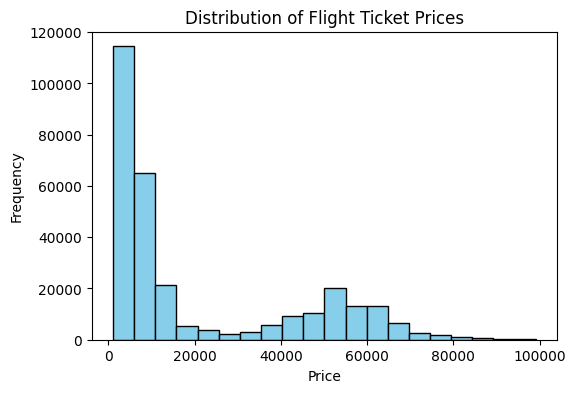

In [ ]:
plt.figure(figsize=(6, 4))
plt.hist(df['price'], bins=20, color='skyblue', edgecolor='black')
plt.title('Distribution of Flight Ticket Prices')
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.show()

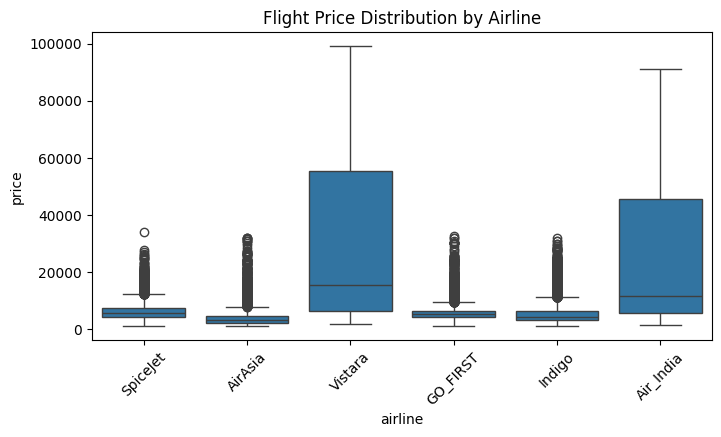

In [ ]:


plt.figure(figsize=(8,4))
sns.boxplot(x='airline', y='price', data=df)
plt.xticks(rotation=45)
plt.title("Flight Price Distribution by Airline")
plt.show()

In [ ]:
#Identify Cat and Numeric data
categorical_cols = X.select_dtypes(include=['object']).columns
numerical_cols = X.select_dtypes(exclude=['object']).columns

print("Categorical:", categorical_cols)
print("Numerical:", numerical_cols)

Categorical: Index([], dtype='object')
Numerical: Index(['duration', 'days_left', 'airline_Air_India', 'airline_GO_FIRST',
       'airline_Indigo', 'airline_SpiceJet', 'airline_Vistara',
       'flight_6E-105', 'flight_6E-113', 'flight_6E-121',
       ...
       'arrival_time_Evening', 'arrival_time_Late_Night',
       'arrival_time_Morning', 'arrival_time_Night',
       'destination_city_Chennai', 'destination_city_Delhi',
       'destination_city_Hyderabad', 'destination_city_Kolkata',
       'destination_city_Mumbai', 'class_Economy'],
      dtype='object', length=1590)


In [ ]:
#Random Forest Model
rf = RandomForestRegressor(n_estimators=50, random_state=42)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

r2_rf = r2_score(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))

print("Random Forest R²:", r2_rf)
print("Random Forest RMSE:", rmse_rf)

Random Forest R²: 0.9885147902228859
Random Forest RMSE: 2430.1803719683885


In [ ]:

comparison = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest"],
    "R2 Score": [r2_lr, r2_rf],
    "RMSE": [rmse_lr, rmse_rf]
})

print(comparison)

               Model  R2 Score         RMSE
0  Linear Regression  0.926012  6168.091246
1      Random Forest  0.988515  2430.180372


In [ ]:
#Feature Importance
#Which factors most influence flight ticket prices (e.g., days_left, class, airline, route).

importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": rf.feature_importances_
})

importance = importance.sort_values(by="Importance", ascending=False)

print(importance.head(10))

                         Feature  Importance
1589               class_Economy    0.879571
0                       duration    0.048385
1                      days_left    0.017791
2              airline_Air_India    0.005828
6                airline_Vistara    0.004442
1585      destination_city_Delhi    0.003788
1568           source_city_Delhi    0.003314
1571          source_city_Mumbai    0.002067
1588     destination_city_Mumbai    0.002038
1586  destination_city_Hyderabad    0.001897


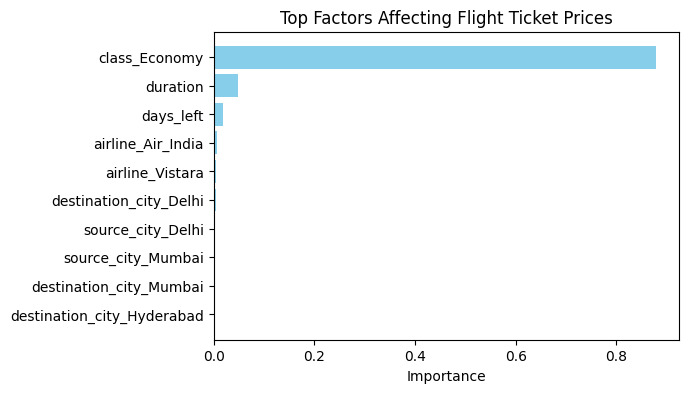

In [ ]:

# Select the top 10 features for plotting.
top_features = importance.head(10)

# Plot
plt.figure(figsize=(6,4))
plt.barh(top_features["Feature"], top_features["Importance"], color='skyblue')
plt.gca().invert_yaxis()
plt.title("Top Factors Affecting Flight Ticket Prices")
plt.xlabel("Importance")
plt.show()

In [ ]:
#Cheapest Route to Prmote
route_price = df.groupby(['source_city','destination_city'])['price'].mean().reset_index()

cheapest_routes = route_price.sort_values(by='price').head(10)

cheapest_routes

,source_city,destination_city,price
17,Hyderabad,Delhi,17243.945685
12,Delhi,Hyderabad,17345.011578
1,Bangalore,Delhi,17722.386740
10,Delhi,Bangalore,17880.216315
27,Mumbai,Delhi,18724.488824
6,Chennai,Delhi,18981.398344
14,Delhi,Mumbai,19355.829812
11,Delhi,Chennai,19367.994341
22,Kolkata,Delhi,19412.826575
19,Hyderabad,Mumbai,20079.127484


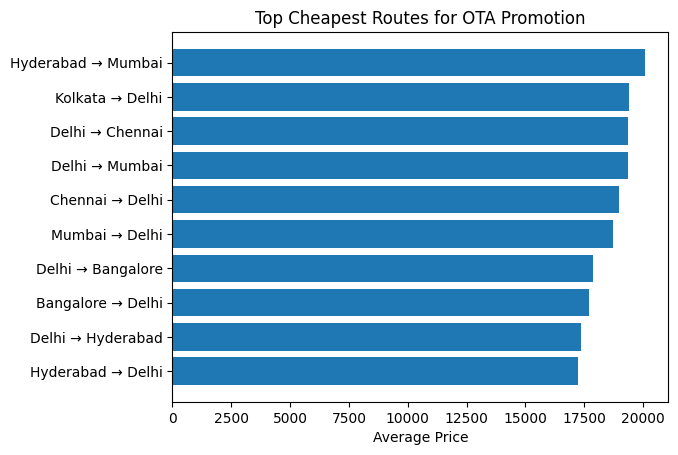

In [ ]:
#Visulization
plt.figure()

plt.barh(
    cheapest_routes['source_city'] + " → " + cheapest_routes['destination_city'],
    cheapest_routes['price']
)

plt.title("Top Cheapest Routes for OTA Promotion")
plt.xlabel("Average Price")
plt.show()

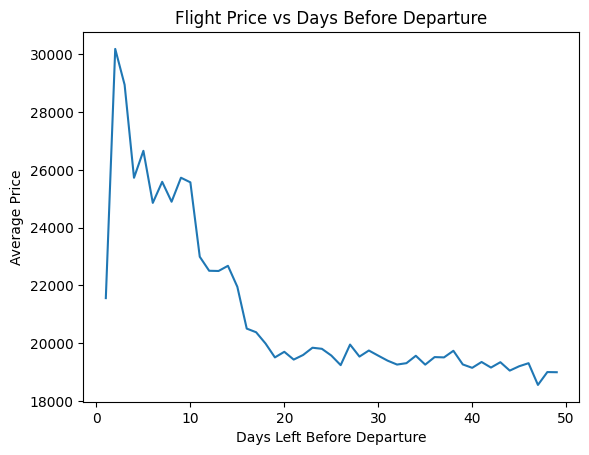

In [ ]:
#Price Trend Vs Days left befor departure
days_price = df.groupby('days_left')['price'].mean().reset_index()

plt.figure()
plt.plot(days_price['days_left'], days_price['price'])
plt.title("Flight Price vs Days Before Departure")
plt.xlabel("Days Left Before Departure")
plt.ylabel("Average Price")
plt.show()

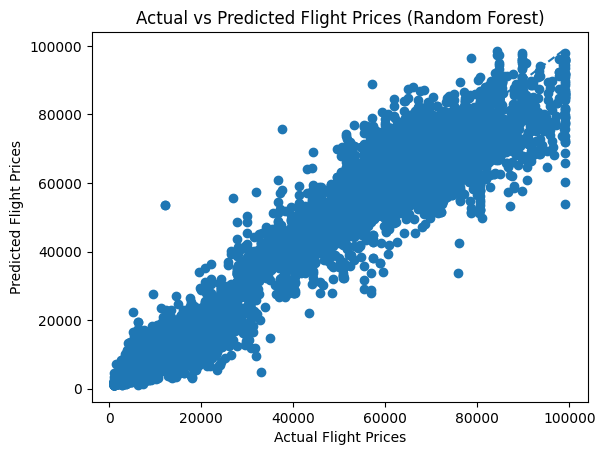

In [ ]:
plt.figure()

plt.scatter(y_test, y_pred_rf)

# Perfect prediction line
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         linestyle="--")

plt.xlabel("Actual Flight Prices")
plt.ylabel("Predicted Flight Prices")
plt.title("Actual vs Predicted Flight Prices (Random Forest)")

plt.show()

Managerial Decisions & Actions:
From a business perspective, this insight is very valuable. For example, days before departure strongly affects ticket prices, which means that prices typically increase as the departure date approaches. This information can help an OTA platform send timely booking reminders or promotions to customers.
Similarly, airline and travel class significantly influence ticket pricing, which allows the platform to highlight cheaper alternatives or premium options based on customer preferences.
Flight duration also affects pricing, which helps the platform recommend flights that balance cost and travel time.
